# Aula 04 Hands-On — ResNet Pequena, Transfer Learning e Grad-CAM

## Contexto
Nesta prática, vamos simular um cenário muito comum fora dos grandes laboratórios: poucos dados rotulados no domínio-alvo e necessidade de reutilizar representação aprendida antes. Em vez de depender de downloads externos, construiremos um problema sintético de formas geométricas que preserva a lógica central de transfer learning e explicabilidade.

## Objetivos de aprendizagem
- Pré-treinar um backbone residual em um domínio-fonte limpo e transferi-lo para um domínio-alvo mais difícil.
- Comparar treinamento do zero, `feature extraction` com backbone congelado e fine-tuning completo.
- Medir desempenho com acurácia, macro-F1 e balanced accuracy sob baixa amostragem.
- Aplicar Grad-CAM para inspecionar onde a rede concentrou evidência visual nas decisões.

## Pergunta experimental e hipótese
**Pergunta:** quando o conjunto-alvo é pequeno e visualmente mais ruidoso do que o domínio-fonte, vale a pena reutilizar um backbone pré-treinado?

**Hipótese:**
- O treinamento do zero deve servir como baseline honesto, mas sofrer mais com variância e menor eficiência amostral.
- O backbone pré-treinado deve oferecer melhor ponto de partida, sobretudo no regime congelado e no fine-tuning leve.
- Grad-CAM deve destacar a região da forma principal e ajudar a detectar casos em que o modelo se apoia demais no ruído de fundo.

## Setup, imports e semente de reprodutibilidade
Como o objetivo é isolar o fenômeno de transferência, geramos os dados dentro do próprio notebook. A semente fixa controla o sorteio de posições, rotações, ruído e particionamento entre treino, validação e teste.

In [1]:
import os
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image, ImageDraw
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42  # para mochileiros
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# reprodutibilidade em GPU: convoluções e reduções determinísticas
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 32
CLASSES = ['circulo', 'quadrado', 'triangulo', 'cruz']
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.precision', 4)  # tabelas com 4 casas, como nos materiais da aula
device

'cuda'

## Geração do dataset-fonte e do dataset-alvo
O domínio-fonte terá formas limpas e bem centralizadas. O domínio-alvo adiciona ruído, rotações, deslocamento, mudanças de contraste e menos exemplos por classe. Essa construção deixa explícita a pergunta que queremos responder: a representação visual aprendida em um regime mais fácil transfere para um regime mais hostil?

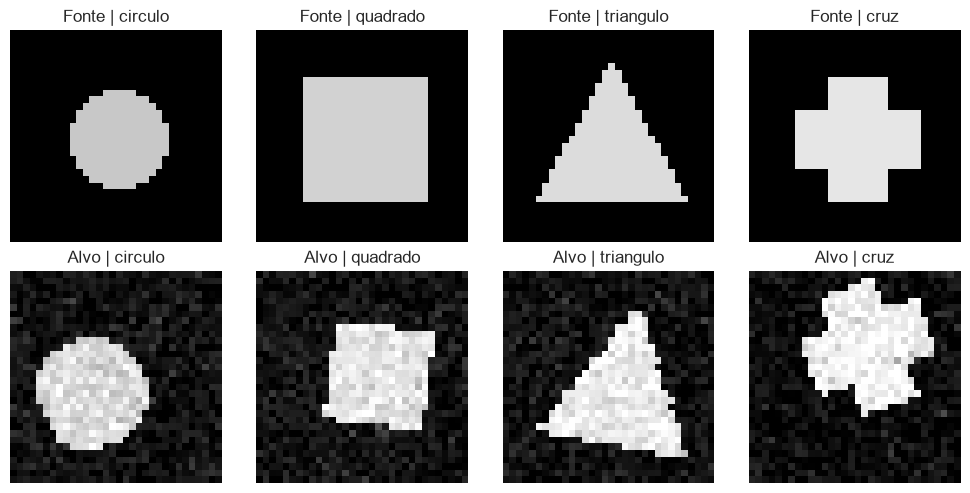

In [2]:
def draw_shape(label, domain='source', seed=SEED):
    rng = np.random.default_rng(seed)
    image = Image.new('L', (IMG_SIZE, IMG_SIZE), color=0)
    draw = ImageDraw.Draw(image)

    center = np.array([IMG_SIZE // 2, IMG_SIZE // 2])
    if domain == 'target':
        center += rng.integers(-4, 5, size=2)
    radius = int(rng.integers(7, 10))

    if label == 0:  # circulo
        box = [center[0] - radius, center[1] - radius, center[0] + radius, center[1] + radius]
        draw.ellipse(box, fill=200)
    elif label == 1:  # quadrado
        box = [center[0] - radius, center[1] - radius, center[0] + radius, center[1] + radius]
        draw.rectangle(box, fill=210)
    elif label == 2:  # triangulo
        points = [
            (center[0], center[1] - radius - 2),
            (center[0] - radius - 2, center[1] + radius),
            (center[0] + radius + 2, center[1] + radius),
        ]
        draw.polygon(points, fill=220)
    else:  # cruz
        thickness = 4
        draw.rectangle([center[0] - thickness, center[1] - radius, center[0] + thickness, center[1] + radius], fill=230)
        draw.rectangle([center[0] - radius, center[1] - thickness, center[0] + radius, center[1] + thickness], fill=230)

    if domain == 'target':
        angle = int(rng.integers(-25, 26))
        image = image.rotate(angle, fillcolor=0)
        arr = np.asarray(image, dtype=np.float32)
        arr += rng.normal(0, 18, size=arr.shape)
        arr += rng.uniform(0, 30)
        arr = np.clip(arr, 0, 255)
        return arr / 255.0

    return np.asarray(image, dtype=np.float32) / 255.0

def build_dataset(samples_per_class, domain='source', base_seed=SEED):
    images, labels = [], []
    for label in range(len(CLASSES)):
        for idx in range(samples_per_class):
            images.append(draw_shape(label, domain=domain, seed=base_seed + label * 1000 + idx))
            labels.append(label)
    return np.stack(images).astype(np.float32), np.array(labels, dtype=np.int64)

X_source, y_source = build_dataset(220, domain='source')
X_target, y_target = build_dataset(70, domain='target')

X_source_train, X_source_val, y_source_train, y_source_val = train_test_split(
    X_source, y_source, test_size=0.2, stratify=y_source, random_state=SEED
)
X_target_train, X_target_temp, y_target_train, y_target_temp = train_test_split(
    X_target, y_target, test_size=0.5, stratify=y_target, random_state=SEED
)
X_target_val, X_target_test, y_target_val, y_target_test = train_test_split(
    X_target_temp, y_target_temp, test_size=0.5, stratify=y_target_temp, random_state=SEED
)

def make_loader(images, labels, batch_size=64, shuffle=False):
    dataset = TensorDataset(
        torch.tensor(images[:, None, :, :], dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

source_train_loader = make_loader(X_source_train, y_source_train, shuffle=True)
source_val_loader = make_loader(X_source_val, y_source_val)
target_train_loader = make_loader(X_target_train, y_target_train, shuffle=True)
target_val_loader = make_loader(X_target_val, y_target_val)
target_test_loader = make_loader(X_target_test, y_target_test)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for row, (images, labels, domain_name) in enumerate(
    [(X_source, y_source, 'Fonte'), (X_target, y_target, 'Alvo')]
 ):
    for col, label in enumerate(range(len(CLASSES))):
        sample_idx = int(np.flatnonzero(labels == label)[0])
        axes[row, col].imshow(images[sample_idx], cmap='gray', interpolation='nearest', vmin=0, vmax=1)
        axes[row, col].set_title(f'{domain_name} | {CLASSES[label]}')
        axes[row, col].axis('off')
plt.tight_layout()

## Baseline e por que ele importa
O baseline principal será treinar a mesma arquitetura do zero no domínio-alvo. Isso nos permite controlar a capacidade da rede e atribuir a diferença de desempenho ao efeito da transferência, não a uma mudança de modelo.

In [3]:
regimes = ['scratch', 'frozen_transfer', 'full_finetune']
regimes

['scratch', 'frozen_transfer', 'full_finetune']

## Método principal
A arquitetura principal é uma mini-ResNet com dois blocos residuais. Ela é pequena o bastante para CPU, mas suficiente para demonstrar skip connections, reutilização de backbone e Grad-CAM sobre a última convolução.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + residual)
        return out

class TinyResNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.block1 = ResidualBlock(16)
        self.downsample = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.block2 = ResidualBlock(32)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(32, num_classes)

    def forward_features(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.downsample(x)
        x = self.block2(x)
        return x

    def forward(self, x):
        features = self.forward_features(x)
        pooled = self.pool(features).flatten(1)
        return self.classifier(pooled)

def evaluate_model(model, loader, criterion):
    model.eval()
    losses, preds_list, targets_list = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            losses.append(criterion(logits, yb).item())
            preds_list.append(logits.argmax(dim=1).cpu().numpy())
            targets_list.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_list)
    y_pred = np.concatenate(preds_list)
    return {
        'loss': float(np.mean(losses)),
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'y_true': y_true,
        'y_pred': y_pred,
    }

def train_model(model, train_loader, val_loader, epochs=12, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history, best_state, best_val_loss = [], None, float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        train_metrics = evaluate_model(model, train_loader, criterion)
        val_metrics = evaluate_model(model, val_loader, criterion)
        history.append({
            'epoch': epoch,
            'train_loss': train_metrics['loss'],
            'train_accuracy': train_metrics['accuracy'],
            'val_loss': val_metrics['loss'],
            'val_accuracy': val_metrics['accuracy'],
        })
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return pd.DataFrame(history), criterion

def clone_model(model):
    cloned = TinyResNet(num_classes=len(CLASSES)).to(device)
    cloned.load_state_dict(copy.deepcopy(model.state_dict()))
    return cloned

## Métricas e interpretação
Acurácia é útil como leitura inicial, mas não basta quando queremos comparar regimes de adaptação com poucos exemplos. Por isso acompanhamos também macro-F1 e balanced accuracy. Se a transferência estiver ajudando de fato, essas métricas devem melhorar juntas e não apenas pela classe majoritária.

In [5]:
def freeze_backbone(model):
    for name, parameter in model.named_parameters():
        if not name.startswith('classifier'):
            parameter.requires_grad = False
    return model

def unfreeze_all(model):
    for parameter in model.parameters():
        parameter.requires_grad = True
    return model

## Execução do treinamento e da avaliação
O protocolo tem duas etapas. Primeiro pré-treinamos a mini-ResNet no domínio-fonte. Em seguida comparamos três regimes no domínio-alvo: treino do zero, backbone congelado e fine-tuning completo. O objetivo é observar se o ganho de transferência aparece com o mesmo modelo e menos dados. Além das curvas, a célula exibe a tabela `results_df` e os históricos por época do pré-treino (`source_history`) e do treino do zero (`scratch_history`) — é neste último que o colapso fica visível.

results_df — métricas no conjunto de teste do domínio-alvo (70 imagens):


,regime,accuracy,macro_f1,balanced_accuracy
0,Treino do zero,0.2571,0.1023,0.2500
1,Backbone congelado,0.7000,0.6974,0.6961
2,Fine-tuning completo,0.7429,0.7393,0.7435



source_history — pré-treino no domínio-fonte, época a época:


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.4288,0.2500,1.4273,0.2500
1,2,1.9163,0.2500,1.9059,0.2500
2,3,1.7307,0.2500,1.7157,0.2500
3,4,0.6696,0.7202,0.6554,0.7784
4,5,0.1980,1.0000,0.1965,1.0000
5,6,0.0906,1.0000,0.0910,1.0000
6,7,0.0524,1.0000,0.0521,1.0000
7,8,0.0331,1.0000,0.0332,1.0000
8,9,0.0279,1.0000,0.0279,1.0000
9,10,0.0227,1.0000,0.0228,1.0000



scratch_history — treino do zero no domínio-alvo, época a época:


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.3964,0.25,1.4285,0.2429
1,2,1.4040,0.25,1.4483,0.2429
2,3,1.4017,0.25,1.4956,0.2429
3,4,1.5904,0.25,1.5914,0.2429
4,5,1.7720,0.25,1.7264,0.2429
5,6,1.7613,0.25,1.9034,0.2429
6,7,1.9505,0.25,2.0697,0.2429
7,8,2.1520,0.25,2.2255,0.2429
8,9,2.3290,0.25,2.4168,0.2429
9,10,2.4339,0.25,2.4811,0.2429


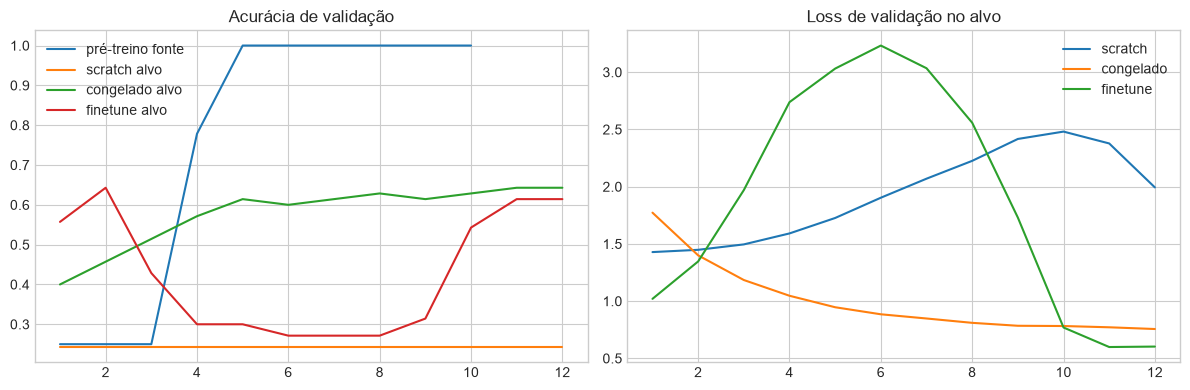

In [6]:
source_model = TinyResNet(num_classes=len(CLASSES)).to(device)
source_history, source_criterion = train_model(source_model, source_train_loader, source_val_loader, epochs=10, lr=1e-3)

scratch_model = TinyResNet(num_classes=len(CLASSES)).to(device)
scratch_history, criterion = train_model(scratch_model, target_train_loader, target_val_loader, epochs=12, lr=1e-3)
scratch_metrics = evaluate_model(scratch_model, target_test_loader, criterion)

frozen_model = freeze_backbone(clone_model(source_model))
frozen_history, criterion = train_model(frozen_model, target_train_loader, target_val_loader, epochs=12, lr=2e-3)
frozen_metrics = evaluate_model(frozen_model, target_test_loader, criterion)

finetune_model = unfreeze_all(clone_model(source_model))
finetune_history, criterion = train_model(finetune_model, target_train_loader, target_val_loader, epochs=12, lr=5e-4)
finetune_metrics = evaluate_model(finetune_model, target_test_loader, criterion)

results_df = pd.DataFrame([
    {'regime': 'Treino do zero', **{k: scratch_metrics[k] for k in ['accuracy', 'macro_f1', 'balanced_accuracy']}},
    {'regime': 'Backbone congelado', **{k: frozen_metrics[k] for k in ['accuracy', 'macro_f1', 'balanced_accuracy']}},
    {'regime': 'Fine-tuning completo', **{k: finetune_metrics[k] for k in ['accuracy', 'macro_f1', 'balanced_accuracy']}},
])
print('results_df — métricas no conjunto de teste do domínio-alvo (70 imagens):')
display(results_df)
print('\nsource_history — pré-treino no domínio-fonte, época a época:')
display(source_history)
print('\nscratch_history — treino do zero no domínio-alvo, época a época:')
display(scratch_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(source_history['epoch'], source_history['val_accuracy'], label='pré-treino fonte')
axes[0].plot(scratch_history['epoch'], scratch_history['val_accuracy'], label='scratch alvo')
axes[0].plot(frozen_history['epoch'], frozen_history['val_accuracy'], label='congelado alvo')
axes[0].plot(finetune_history['epoch'], finetune_history['val_accuracy'], label='finetune alvo')
axes[0].set_title('Acurácia de validação')
axes[0].legend()

axes[1].plot(scratch_history['epoch'], scratch_history['val_loss'], label='scratch')
axes[1].plot(frozen_history['epoch'], frozen_history['val_loss'], label='congelado')
axes[1].plot(finetune_history['epoch'], finetune_history['val_loss'], label='finetune')
axes[1].set_title('Loss de validação no alvo')
axes[1].legend()
plt.tight_layout()

## Análise de erro, limitações e próximo experimento
O passo seguinte não é apenas olhar a métrica agregada, mas verificar onde o modelo erra e em que região da imagem ele concentra atenção. Grad-CAM entra aqui como ferramenta diagnóstica: ele não prova causalidade, mas ajuda a detectar se a rede está olhando a forma principal ou explorando atalhos espúrios do fundo. A matriz de confusão é impressa em números (fine-tuning e treino do zero) antes da figura, para que a contagem de acertos e o colapso numa única classe possam ser lidos diretamente.

Matriz de confusão — fine-tuning completo (linhas = real, colunas = predito; ordem: ['circulo', 'quadrado', 'triangulo', 'cruz'] )
[[10  6  0  2]
 [ 0  9  0  8]
 [ 0  0 16  2]
 [ 0  0  0 17]]
Acertos na diagonal: 52 de 70

Matriz de confusão — treino do zero (mesma ordem de classes):
[[18  0  0  0]
 [17  0  0  0]
 [18  0  0  0]
 [17  0  0  0]]
Acertos do backbone congelado: 49 de 70


,regime,accuracy,macro_f1,balanced_accuracy
0,Treino do zero,0.2571,0.1023,0.2500
1,Backbone congelado,0.7000,0.6974,0.6961
2,Fine-tuning completo,0.7429,0.7393,0.7435


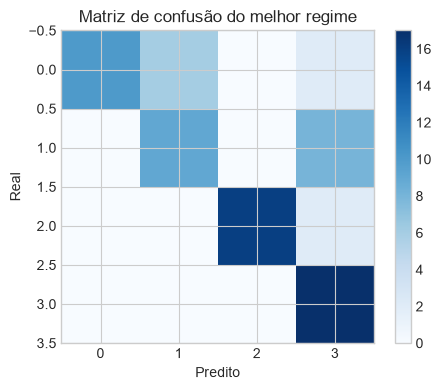

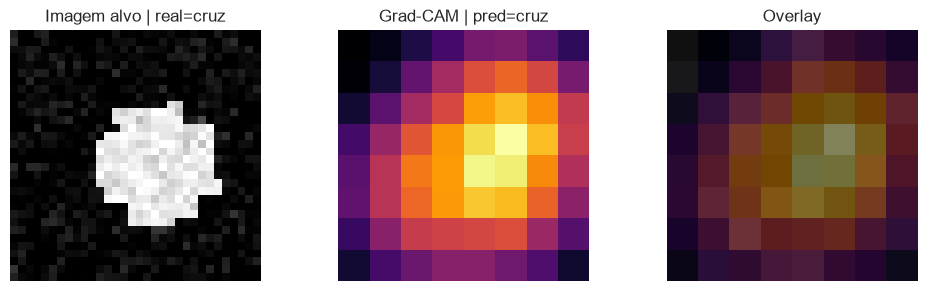

In [7]:
def grad_cam(model, image_tensor, target_class=None):
    activations = []
    gradients = []

    def forward_hook(module, inputs, output):
        activations.append(output.detach())

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    handle_f = model.block2.conv2.register_forward_hook(forward_hook)
    handle_b = model.block2.conv2.register_full_backward_hook(backward_hook)

    model.eval()
    logits = model(image_tensor)
    if target_class is None:
        target_class = int(logits.argmax(dim=1).item())

    model.zero_grad()
    logits[:, target_class].backward()

    weights = gradients[0].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((weights * activations[0]).sum(dim=1)).squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    handle_f.remove()
    handle_b.remove()
    return cam, target_class

cm = confusion_matrix(finetune_metrics['y_true'], finetune_metrics['y_pred'])
print('Matriz de confusão — fine-tuning completo (linhas = real, colunas = predito; ordem:', CLASSES, ')')
print(cm)
print('Acertos na diagonal:', int(np.trace(cm)), 'de', int(cm.sum()))
cm_scratch = confusion_matrix(scratch_metrics['y_true'], scratch_metrics['y_pred'])
print('\nMatriz de confusão — treino do zero (mesma ordem de classes):')
print(cm_scratch)
cm_frozen = confusion_matrix(frozen_metrics['y_true'], frozen_metrics['y_pred'])
print('Acertos do backbone congelado:', int(np.trace(cm_frozen)), 'de', int(cm_frozen.sum()))
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de confusão do melhor regime')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.colorbar()
plt.tight_layout()

sample_idx = int(np.where(finetune_metrics['y_true'] == finetune_metrics['y_pred'])[0][0])
sample = torch.tensor(X_target_test[sample_idx:sample_idx+1, None, :, :], dtype=torch.float32).to(device)
cam, pred_class = grad_cam(finetune_model, sample)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(X_target_test[sample_idx], cmap='gray')
axes[0].set_title(f'Imagem alvo | real={CLASSES[y_target_test[sample_idx]]}')
axes[0].axis('off')
axes[1].imshow(cam, cmap='inferno')
axes[1].set_title(f'Grad-CAM | pred={CLASSES[pred_class]}')
axes[1].axis('off')
axes[2].imshow(X_target_test[sample_idx], cmap='gray')
axes[2].imshow(cam, cmap='inferno', alpha=0.45)
axes[2].set_title('Overlay')
axes[2].axis('off')
plt.tight_layout()

results_df

## Fechamento e próximos passos
Se a hipótese estiver correta, o backbone pré-treinado deve oferecer vantagem clara em regime de poucos dados, especialmente quando combinado com fine-tuning controlado. A próxima aula muda de domínio, mas preserva a mesma lógica científica: vamos estudar sequências temporais e mostrar quando a memória explícita de RNN, GRU e LSTM realmente melhora a previsão.